# Titanic Dataset prediction by survival rate

In [43]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

In [44]:
# load the data
df_train = pd.read_csv('Dataset/train.csv')
df_test = pd.read_csv('Dataset/test.csv')
submission = pd.read_csv('Dataset/gender_submission.csv')

In [45]:
submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [46]:
submission.shape

(418, 2)

In [47]:
submission.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB


In [48]:
submission["Survived"].unique()

array([0, 1])

In [49]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [50]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [51]:
submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


# Let's explore the data df_train.csv

In [52]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [53]:
(df_train.isnull().sum() / len(df_train) * 100 ).sort_values(ascending=False)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64

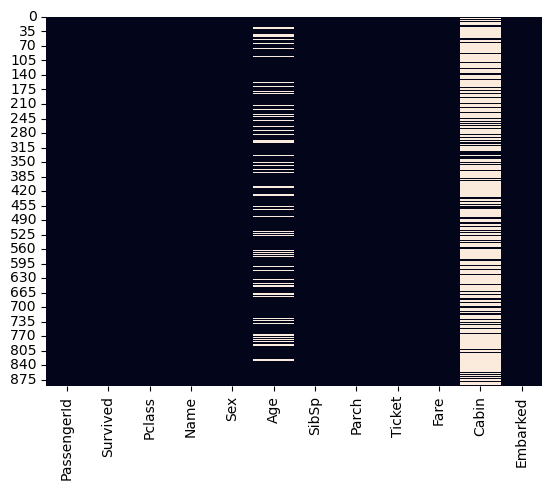

In [54]:
# plot the null values
sns.heatmap(df_train.isnull(), cbar=False)
plt.show()

In [55]:
df_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [56]:
df = df_train.copy()

In [57]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Example: define categorical and numeric columns
categorical_cols = ['Cabin', 'Embarked']  # replace with your dataset
numeric_cols = ['Age']                     # replace with your dataset

# Function to impute missing values
def impute_missing(df, col, categorical=True):
    df_not_null = df[df[col].notnull()]
    df_null = df[df[col].isnull()]

    X = df_not_null.drop(col, axis=1)
    y = df_not_null[col]

    # Encode categorical variables in X
    le = LabelEncoder()
    for c in X.select_dtypes(include=['object','category']).columns:
        X[c] = le.fit_transform(X[c].astype(str))

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Choose model
    model = RandomForestClassifier() if categorical else RandomForestRegressor()
    model.fit(X_train, y_train)

    # Prepare missing rows
    if len(df_null) > 0:
        X_missing = df_null.drop(col, axis=1)
        for c in X_missing.select_dtypes(include=['object','category']).columns:
            X_missing[c] = le.fit_transform(X_missing[c].astype(str))
        # Predict missing values
        df.loc[df[col].isnull(), col] = model.predict(X_missing)

    return df[col]

# Find all columns with missing values
missing_data_cols = df.isnull().sum()[df.isnull().sum() > 0].index.tolist()

# Impute all missing values
for col in missing_data_cols:
    print(f"Imputing missing values for '{col}' ({round(df[col].isnull().mean()*100,2)}%)")
    if col in categorical_cols:
        df[col] = impute_missing(df, col, categorical=True)
    elif col in numeric_cols:
        df[col] = impute_missing(df, col, categorical=False)

# Check if any missing values remain
print("\nRemaining missing values per column:")
print(df.isnull().sum())

Imputing missing values for 'Age' (19.87%)
Imputing missing values for 'Cabin' (77.1%)
Imputing missing values for 'Embarked' (0.22%)

Remaining missing values per column:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    str    
 11  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


# Function to impute missing values from df

In [59]:
'''
This function was used to impute the missing values in the dataset. It takes in the dataframe, the column to be imputed, and 
a boolean indicating whether the column is categorical or continuous. It then trains a Random Forest model on the
non-missing data and uses it to predict the missing values. The function returns the imputed column. But instead of using this function,
we created a short function from the same function and used it above to impute missing values in the dataset.

#function start from here:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, accuracy_score, precision_score, r2_score, mean_squared_error
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Cabin', 'Embarked']
bool_cols = []
numeric_cols = ['Age']

missing_data_cols = df.isnull().sum()[df.isnull().sum() > 0].index.tolist()

# define the function to impute the missing values in thal column

def impute_categorical_missing_data(passed_col):
    
    df_null = df[df[passed_col].isnull()]
    df_not_null = df[df[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]
    
    other_missing_cols = [col for col in missing_data_cols if col != passed_col]
    
    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    if passed_col in bool_cols:
        y = label_encoder.fit_transform(y)
        
    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_classifier = RandomForestClassifier()

    rf_classifier.fit(X_train, y_train)

    y_pred = rf_classifier.predict(X_test)

    acc_score = accuracy_score(y_test, y_pred)

    print("The feature '"+ passed_col+ "' has been imputed with", round((acc_score * 100), 2), "accuracy\n")

    X = df_null.drop(passed_col, axis=1)

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass
                
    if len(df_null) > 0: 
        df_null[passed_col] = rf_classifier.predict(X)
        if passed_col in bool_cols:
            df_null[passed_col] = df_null[passed_col].map({0: False, 1: True})
        else:
            pass
    else:
        pass

    df_combined = pd.concat([df_not_null, df_null])
    
    return df_combined[passed_col]

def impute_continuous_missing_data(passed_col):
    
    df_null = df[df[passed_col].isnull()]
    df_not_null = df[df[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]
    
    other_missing_cols = [col for col in missing_data_cols if col != passed_col]
    
    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])
    
    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_regressor = RandomForestRegressor()

    rf_regressor.fit(X_train, y_train)

    y_pred = rf_regressor.predict(X_test)

    print("MAE =", mean_absolute_error(y_test, y_pred), "\n")
    print("RMSE =", mean_squared_error(y_test, y_pred, squared=False), "\n")
    print("R2 =", r2_score(y_test, y_pred), "\n")

    X = df_null.drop(passed_col, axis=1)

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass
                
    if len(df_null) > 0: 
        df_null[passed_col] = rf_regressor.predict(X)
    else:
        pass

    df_combined = pd.concat([df_not_null, df_null])
    
    return df_combined[passed_col]

# remove warning
import warnings
warnings.filterwarnings('ignore')

# impute missing values using our functions
for col in missing_data_cols:
    print("Missing Values", col, ":", str(round((df[col].isnull().sum() / len(df)) * 100, 2))+"%")
    if col in categorical_cols:
        df[col] = impute_categorical_missing_data(col)
    elif col in numeric_cols:
        df[col] = impute_continuous_missing_data(col)
    else:
        pass

(df.isnull().sum() / len(df) * 100 ).sort_values(ascending=False)
'''

'\nThis function was used to impute the missing values in the dataset. It takes in the dataframe, the column to be imputed, and \na boolean indicating whether the column is categorical or continuous. It then trains a Random Forest model on the\nnon-missing data and uses it to predict the missing values. The function returns the imputed column. But instead of using this function,\nwe created a short function from the same function and used it above to impute missing values in the dataset.\n\n#function start from here:\nfrom sklearn.ensemble import RandomForestClassifier, RandomForestRegressor\nfrom sklearn.metrics import mean_absolute_error, accuracy_score, precision_score, r2_score, mean_squared_error\nfrom sklearn.experimental import enable_iterative_imputer\nfrom sklearn.impute import IterativeImputer\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.preprocessing import LabelEncoder\n\ncategorical_cols = [\'Cabin\', \'Embarked\']\nbool_cols = []\nnumeric_cols = [\'

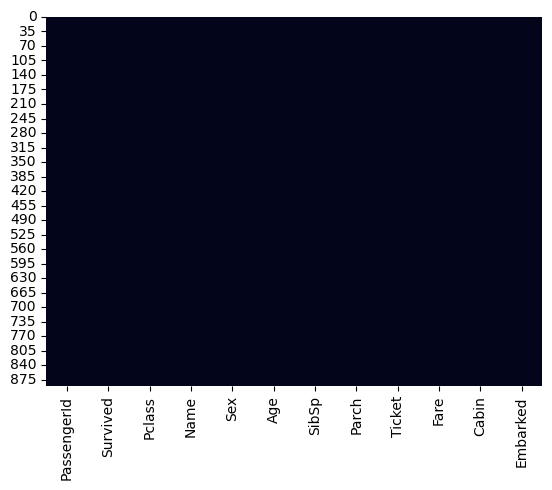

In [60]:
# plot missing values
sns.heatmap(df.isnull(), cbar=False)
plt.show()

Missing values have been imputed or removed from the data set. 

In [61]:
# split the data into X and y
X = df.drop(['Survived', 'Name'], axis=1)
y = df['Survived']

# encode the data
label_encoder = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype == 'category':
        X[col] = label_encoder.fit_transform(X[col])
    else:
        pass
    
# split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
X_train.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
331,332,1,male,45.5,0,0,113043,28.5000,C124,S
733,734,2,male,23.0,0,0,28425,13.0000,D,S
382,383,3,male,32.0,0,0,STON/O 2. 3101293,7.9250,E10,S
704,705,3,male,26.0,1,0,350025,7.8542,E10,S
813,814,3,female,6.0,4,2,347082,31.2750,C23 C25 C27,S


In [63]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 712 entries, 331 to 102
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Sex          712 non-null    str    
 3   Age          712 non-null    float64
 4   SibSp        712 non-null    int64  
 5   Parch        712 non-null    int64  
 6   Ticket       712 non-null    str    
 7   Fare         712 non-null    float64
 8   Cabin        712 non-null    str    
 9   Embarked     712 non-null    str    
dtypes: float64(2), int64(4), str(4)
memory usage: 61.2 KB


In [64]:
le = LabelEncoder()

# encode training data
for col in X_test.columns:
    if X_test[col].dtype == 'object' or X_test[col].dtype == 'category' or X_test[col].dtype == 'str':
        X_test[col] = le.fit_transform(X_test[col].astype(str))

In [65]:
#encode the data before training the model
le = LabelEncoder()
for col in X_train.columns:
    if X_train[col].dtype == 'object' or X_train[col].dtype == 'category' or X_train[col].dtype == 'str':
        X_train[col] = le.fit_transform(X_train[col])
    else:
        pass

In [66]:
#drop the ticket and cabin column and reset the index
X_train = X_train.drop(['Ticket', 'Cabin'], axis=1)

In [67]:
# Drop Ticket and Cabin from X_test to match X_train shape
X_test = X_test.drop(['Ticket', 'Cabin'], axis=1)

In [68]:
X_train.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,332,1,1,45.5,0,0,28.5000,2
733,734,2,1,23.0,0,0,13.0000,2
382,383,3,1,32.0,0,0,7.9250,2
704,705,3,1,26.0,1,0,7.8542,2
813,814,3,0,6.0,4,2,31.2750,2


In [69]:
X_test.info()

<class 'pandas.DataFrame'>
Index: 179 entries, 709 to 10
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  179 non-null    int64  
 1   Pclass       179 non-null    int64  
 2   Sex          179 non-null    int64  
 3   Age          179 non-null    float64
 4   SibSp        179 non-null    int64  
 5   Parch        179 non-null    int64  
 6   Fare         179 non-null    float64
 7   Embarked     179 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 12.6 KB


In [70]:
print("X_train shape:", X_train.shape)
print("X_train type:", type(X_train))
print("y_train shape:", y_train.shape)
print("y_train type:", type(y_train))

X_train shape: (712, 8)
X_train type: <class 'pandas.DataFrame'>
y_train shape: (712,)
y_train type: <class 'pandas.Series'>


In [71]:
X_train.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,332,1,1,45.5,0,0,28.5000,2
733,734,2,1,23.0,0,0,13.0000,2
382,383,3,1,32.0,0,0,7.9250,2
704,705,3,1,26.0,1,0,7.8542,2
813,814,3,0,6.0,4,2,31.2750,2


# Create a Neural Network for Binary Classification

In [72]:
# use tensorflow to create a neural network
import tensorflow as tf

# Building the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(128, activation='relu', 
                          input_shape=(X_train.shape[1],)), # Input layer
    tf.keras.layers.Dense(64, activation='relu'), # Hidden layer 1
    tf.keras.layers.Dense(32, activation='relu'), # Hidden layer 2
    tf.keras.layers.Dense(16, activation='relu'), # Hidden layer 3
    tf.keras.layers.Dense(8, activation='relu'), # Hidden layer 3
    
    tf.keras.layers.Dense(1, activation='sigmoid') # Output layer
])

In [73]:
# # Compile the model
# model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# # Training the model
# model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1)

# # Evaluating the model on the test set
# model.evaluate(X_test, y_test)

In [74]:
X_test.info()

<class 'pandas.DataFrame'>
Index: 179 entries, 709 to 10
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  179 non-null    int64  
 1   Pclass       179 non-null    int64  
 2   Sex          179 non-null    int64  
 3   Age          179 non-null    float64
 4   SibSp        179 non-null    int64  
 5   Parch        179 non-null    int64  
 6   Fare         179 non-null    float64
 7   Embarked     179 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 12.6 KB


Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5885 - loss: 1.9768 - val_accuracy: 0.7151 - val_loss: 0.5541
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5576 - loss: 1.0408 - val_accuracy: 0.6145 - val_loss: 0.9604
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5801 - loss: 0.8200 - val_accuracy: 0.7654 - val_loss: 0.5699
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6545 - loss: 0.6473 - val_accuracy: 0.5754 - val_loss: 0.6603
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6601 - loss: 0.6234 - val_accuracy: 0.6592 - val_loss: 0.5894
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7008 - loss: 0.6146 - val_accuracy: 0.6145 - val_loss: 0.6075
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6784 - loss: 0.6099 - val_accuracy: 0.7486 - val_loss: 0.5615
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6994 - loss: 0.5910 - val_accuracy: 0.7151 - 

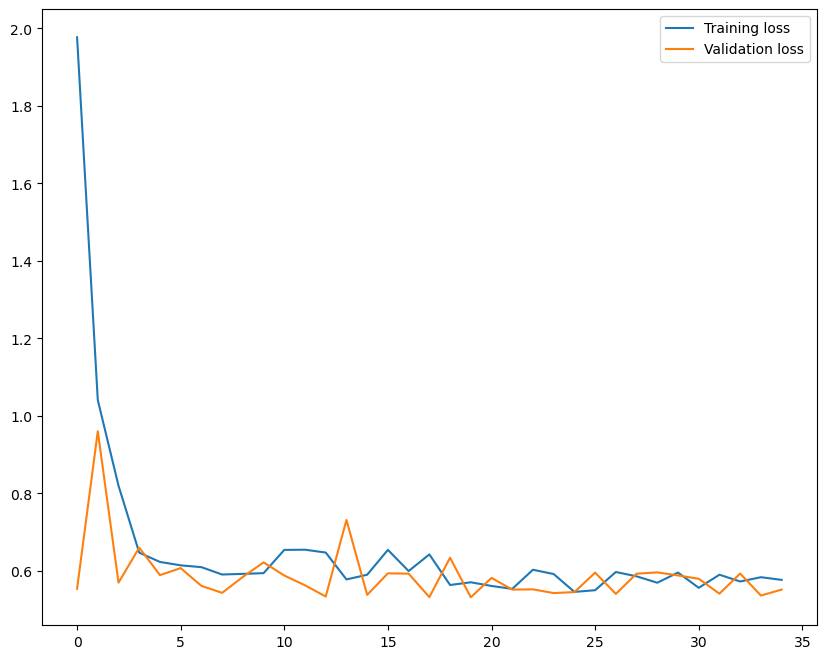

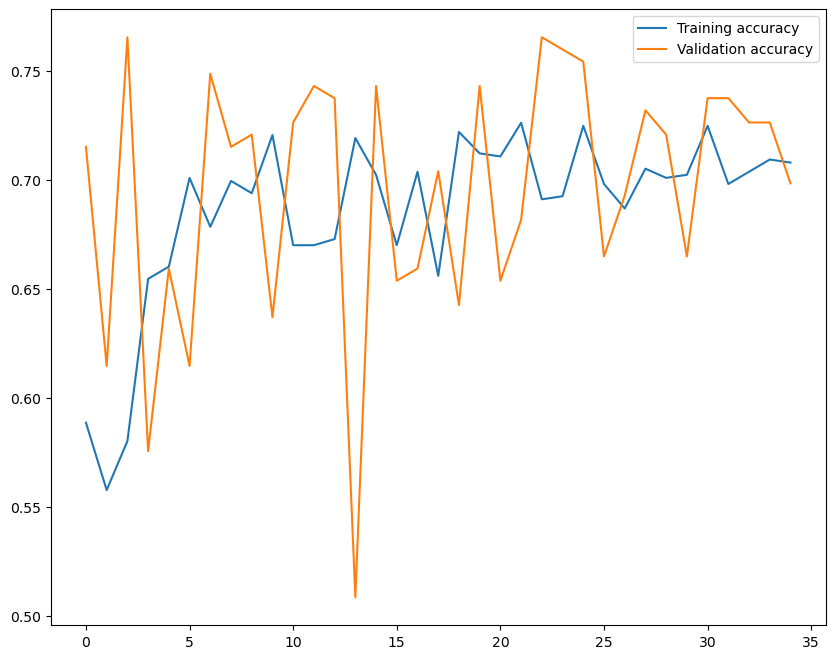

In [75]:
from tensorflow.keras.callbacks import EarlyStopping

# Define the callback function
early_stopping = EarlyStopping(patience=15)


# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# train the model and plot the training and testing loss and accuracy at each epoch
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=30,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

# plot the training and testing loss and accuracy at each epoc
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(history.history['loss'], label='Training loss')
ax.plot(history.history['val_loss'], label='Validation loss')
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(history.history['accuracy'], label='Training accuracy')
ax.plot(history.history['val_accuracy'], label='Validation accuracy')
ax.legend()
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


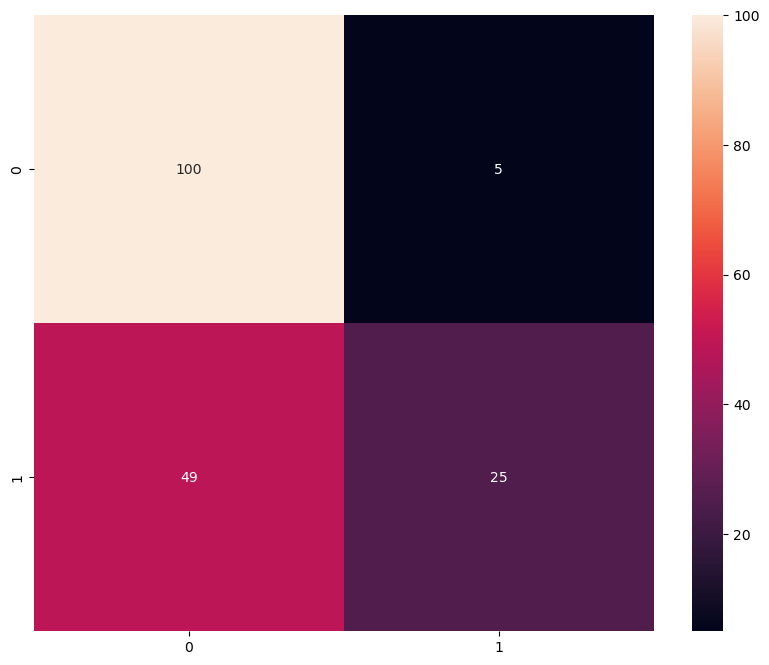

In [76]:
# create a confusion matrix
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

cm = confusion_matrix(y_test, y_pred)

# plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='g')
plt.show()

In [78]:
# creata a submission file
X_submission = df_test.drop('Name', axis=1)

for col in X_submission.columns:
    if X_submission[col].dtype == 'object' or X_submission[col].dtype == 'category' or X_submission[col].dtype == 'str':
        X_submission[col] = label_encoder.fit_transform(X_submission[col])
    else:
        pass
    
# Drop Ticket and Cabin columns to match the training data
X_submission = X_submission.drop(['Ticket', 'Cabin'], axis=1)

# Handle missing values in X_submission (fill NaN with median/mode)
for col in X_submission.columns:
    if X_submission[col].isnull().sum() > 0:
        X_submission[col].fillna(X_submission[col].median(), inplace=True)

y_submission = model.predict(X_submission)
y_submission = (y_submission > 0.5)

submission['Survived'] = y_submission.astype(int)

submission.to_csv('submission.csv', index=False)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


---